# Notebook 02: Data Cleaning, Audit, & Feature Engineering Pipeline
## Nexora Climate Intelligence | CodeFest Datathon Finals 2026

### Purpose & Objectives
This notebook provides complete transparency into the data cleaning, quality auditing, and feature engineering transformations:
1. **Automated Audit Pipeline:** Execute the canonical data audit script and produce `data/outputs/data_quality_audit.csv`.
2. **Country Clean Table:** Merge `co2_emissions_yearly.csv` and `energy_mix_yearly.csv` into `country_clean.csv` (1,350 rows, 0 nulls).
3. **Zero-Leakage Price Features:** Chronologically sort carbon prices and engineer calendar + strictly shifted autoregressive lags and rolling volatility.
4. **Standardize Events & Temperature:** Standardize dates and binary flags for climate events and regional temperature anomalies.
5. **Canonical Data Verification:** Confirm that `data/processed/` contains all 4 single-source-of-truth datasets.


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(BASE_DIR))

from src.data_loader import audit_and_clean_all
print('Project root:', BASE_DIR.resolve())
print('Loaded canonical data loader from src/data_loader.py')


Project root: C:\Users\ASUS\Desktop\Datathon Finals\nexora-final-challenge
Loaded canonical data loader from src/data_loader.py


---
## 1. Execute Automated Data Quality Audit
Running the automated data cleaning pipeline to generate the canonical datasets and the audit matrix:


In [2]:
audit_df, clean_tables = audit_and_clean_all(BASE_DIR)

print('=== Canonical Data Quality Audit Report ===')
display(audit_df[['dataset_name', 'raw_rows', 'primary_key', 'missing_cells', 'anomalies_detected', 'clean_rows', 'status']])



                     NEXORA DATA QUALITY AUDIT REPORT
[PASS] co2_emissions_yearly.csv
    Raw: 1350 rows x 8 cols | Key: (iso3, year)
    Missing: 0 | Anomalies: None (all emissions and population values positive)
    Action: Standardized snake_case column names
--------------------------------------------------------------------------------
[PASS] energy_mix_yearly.csv
    Raw: 1350 rows x 14 cols | Key: (iso3, year)
    Missing: 0 | Anomalies: Fuel shares sum verified: 99.98% to 100.02%
    Action: Validated 100% fuel share closure; standardized names
--------------------------------------------------------------------------------
[PASS] country_clean.csv (MERGED)
    Raw: 1,350 x 1,350 rows x 8 + 14 cols | Key: (iso3, year)
    Missing: 0 | Anomalies: Zero key mismatch; exactly 50 countries x 27 years
    Action: Inner join on (iso3, year); engineered clean_baseload & fossil_ratio
--------------------------------------------------------------------------------
[PASS] carbon_prices_

,dataset_name,raw_rows,primary_key,missing_cells,anomalies_detected,clean_rows,status
0,co2_emissions_yearly.csv,1350,"(iso3, year)",0,None (all emissions and population values posi...,1350,PASS
1,energy_mix_yearly.csv,1350,"(iso3, year)",0,Fuel shares sum verified: 99.98% to 100.02%,1350,PASS
2,country_clean.csv (MERGED),"1,350 x 1,350","(iso3, year)",0,Zero key mismatch; exactly 50 countries x 27 y...,1350,PASS
3,carbon_prices_daily.csv,15866,"(market, date)",0,"Negative prices: 0, Duplicates: 0",15866,PASS
4,climate_events.csv,50,event_id,0,"Severity scores bounded [6, 10]; 0 duplicates",50,PASS
5,temperature_anomaly_monthly.csv,2528,"(region, year_month)","2,212 in co2_ppm (2212 non-global)",Scientific expected behavior: NASA GISS logs C...,2528,PASS


---
## 2. Detailed Inspection: `country_clean.csv` (Emissions + Energy Mix)
Merged on `(iso3, year)` to ensure synchronized feature engineering for Question 1.2 and Question 3.
Derived features:
- `clean_baseload_pct = nuclear_pct + hydro_pct`
- `fossil_ratio = fossil_total_pct / (renewables_total_pct + 0.01)`
- `coal_to_gas_ratio = coal_pct / (gas_pct + 0.01)`


In [3]:
country_clean = clean_tables['country_clean']
print(f'country_clean dimensions: {country_clean.shape[0]} rows x {country_clean.shape[1]} columns')
print('Missing values count:', country_clean.isnull().sum().sum())

# Inspect derived features
display(country_clean[['year', 'country', 'iso3', 'co2_per_capita_t', 'clean_baseload_pct', 'fossil_ratio', 'coal_to_gas_ratio']].head(8))


country_clean dimensions: 1350 rows x 22 columns
Missing values count: 0


,year,country,iso3,co2_per_capita_t,clean_baseload_pct,fossil_ratio,coal_to_gas_ratio
0,2000,Algeria,DZA,2.67,4.25,20.0452,0.0278
1,2001,Algeria,DZA,2.67,2.31,16.7939,0.0214
2,2002,Algeria,DZA,2.71,2.69,12.9690,0.0325
3,2003,Algeria,DZA,2.76,1.92,22.4797,0.0087
4,2004,Algeria,DZA,2.82,0.95,34.8556,0.0163
5,2005,Algeria,DZA,2.83,3.09,9.7062,0.0000
6,2006,Algeria,DZA,2.91,2.49,18.6859,0.0958
7,2007,Algeria,DZA,3.07,2.38,23.5990,0.0068


---
## 3. Detailed Inspection: `prices_clean.csv` & Zero-Leakage Verification
Verifying that rolling windows and lags are strictly shifted backward by at least 1 day:


In [4]:
prices_clean = clean_tables['prices_clean']
print(f'prices_clean dimensions: {prices_clean.shape[0]} rows x {prices_clean.shape[1]} columns')
print('Missing values count:', prices_clean.isnull().sum().sum())

# Zero-leakage demonstration
eu_sample = prices_clean[prices_clean['market'] == 'EU_ETS'][['date', 'price', 'lag_1', 'lag_2', 'roll_mean_7d', 'roll_std_30d']].tail(8)
display(eu_sample)
print('\nZero Leakage Notice: roll_mean_7d on date T uses prices up to date T-1. No look-ahead bias!')


prices_clean dimensions: 15866 rows x 23 columns
Missing values count: 370


,date,price,lag_1,lag_2,roll_mean_7d,roll_std_30d
9975,2026-04-21,82.54,86.71,83.20,84.4743,2.0718
9976,2026-04-22,83.35,82.54,86.71,84.1400,2.0766
9977,2026-04-23,84.42,83.35,82.54,84.4271,2.0725
9978,2026-04-24,85.38,84.42,83.35,84.4171,2.0622
9979,2026-04-27,84.19,85.38,84.42,84.3986,2.0657
9980,2026-04-28,87.57,84.19,85.38,84.2557,2.0297
9981,2026-04-29,85.59,87.57,84.19,84.8800,2.1419
9982,2026-04-30,85.16,85.59,87.57,84.7200,2.1389



Zero Leakage Notice: roll_mean_7d on date T uses prices up to date T-1. No look-ahead bias!


---
## 4. Detailed Inspection: `events_clean.csv` & `temp_clean.csv`
Standardized climate event flags and monthly temperature anomalies.


In [5]:
events_clean = clean_tables['events_clean']
temp_clean = clean_tables['temp_clean']

print(f'events_clean: {events_clean.shape[0]} rows x {events_clean.shape[1]} columns')
print(f'temp_clean: {temp_clean.shape[0]} rows x {temp_clean.shape[1]} columns')

display(events_clean.head(5))
display(temp_clean.head(5))


events_clean: 50 rows x 11 columns
temp_clean: 2528 rows x 7 columns


,event_id,date,year,month,region,event_type,severity_score,description,is_policy,is_extreme_weather,is_disaster
0,CE001,2003-08-01,2003,8,Europe,heatwave,8,"European heatwave kills 70,000+",0,1,0
1,CE002,2004-12-26,2004,12,Asia,tsunami,9,"Indian Ocean tsunami (227,000 deaths)",0,0,1
2,CE003,2005-08-29,2005,8,USA,hurricane,9,"Hurricane Katrina (~1,800 deaths, $125B)",0,1,0
3,CE004,2008-05-12,2008,5,China,earthquake,8,Sichuan earthquake,0,0,1
4,CE005,2009-12-07,2009,12,global,policy,8,Copenhagen Climate Conference COP15,1,0,0


,year_month,year,month,region,temp_anomaly_c,temp_anomaly_baseline,co2_ppm
0,2000-01,2000,1,Global,0.432,1951-1980,367.44
1,2000-01,2000,1,Arctic,1.500,1951-1980,NaN
2,2000-01,2000,1,Northern_Hemisphere,0.468,1951-1980,NaN
3,2000-01,2000,1,Southern_Hemisphere,0.320,1951-1980,NaN
4,2000-01,2000,1,Tropics,0.272,1951-1980,NaN


---
## 5. Before vs. After Data Comparison Visualizations
Visualizing fuel share correlations against per-capita emissions across all 50 countries:


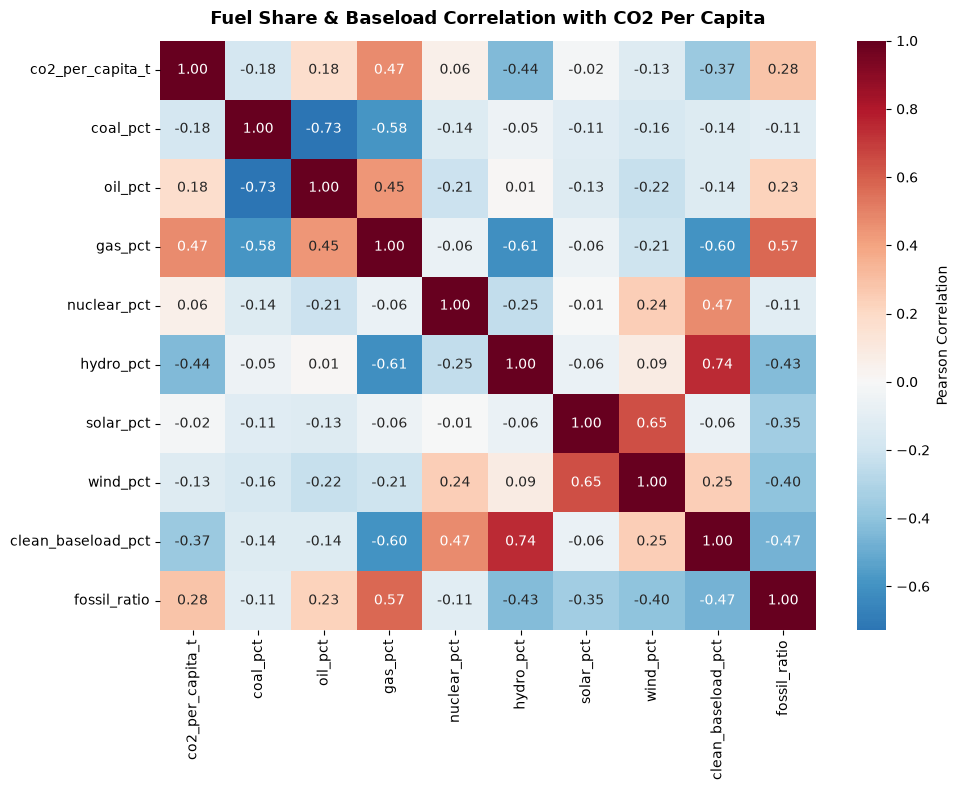

In [6]:
# Correlation matrix of energy mix fuel shares against CO2 per capita
fuel_corr_cols = ['co2_per_capita_t', 'coal_pct', 'oil_pct', 'gas_pct', 'nuclear_pct', 'hydro_pct', 'solar_pct', 'wind_pct', 'clean_baseload_pct', 'fossil_ratio']
corr = country_clean[fuel_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Fuel Share & Baseload Correlation with CO2 Per Capita', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


---
## 6. Canonical Data Hand-off Summary
All four canonical clean datasets are verified and saved in `data/processed/`:
- `data/processed/country_clean.csv` (1,350 rows x 22 columns)
- `data/processed/prices_clean.csv` (15,866 rows x 23 columns)
- `data/processed/events_clean.csv` (50 rows x 11 columns)
- `data/processed/temp_clean.csv` (2,528 rows x 7 columns)

These files form the single source of truth for Question 1, Question 2, and Question 3.
